In [27]:
!pip3 install --user pandas numpy matplotlib pytz xgboost scikit-learn statsmodels joblib optuna

ERROR: Can not perform a '--user' install. User site-packages are not visible in this virtualenv.

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
# Import dei moduli
import pandas as pd

from datetime import datetime, timedelta
import pytz

import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import numpy as np
import xgboost as xgb
from xgboost import plot_importance, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.nonparametric.smoothers_lowess import lowess
import joblib
import warnings
from IPython.display import clear_output
import optuna

In [29]:
# load data
stats_df_tot = pd.read_csv("Statistiche_anno/stat_per_mese_Venezia.csv")

In [30]:
# Fuso orario locale
rome_tz = pytz.timezone('Europe/Rome')

## PREPROCESSING

In [49]:
df = pd.read_csv("carnevale_tot.csv")
df["Timestamp"] = pd.to_datetime(df["Timestamp"], utc=True)
df["Timestamp_local"] = df["Timestamp"].dt.tz_convert('Europe/Rome')
df["giorno_locale"] = df["Timestamp_local"].dt.strftime('%Y-%m-%d %H:%M')
df = df.drop(columns = ['Timestamp','Timestamp_local', 'cod_reg', 'regione', 'cod_pro', 'provincia',
       'cod_com', 'comune', 'comuneace', 'ace','code'])
df = df[['giorno_locale'] + [col for col in df.columns if col != 'giorno_locale']]

In [50]:
# Checking and filling missing values

df_grouped = df.groupby('giorno_locale').sum().reset_index()
df_grouped['giorno_locale'] = pd.to_datetime(df_grouped['giorno_locale'])
df_grouped['anno'] = (df_grouped['giorno_locale']).dt.year

# Creo Lista con Anni considerati
anni = df_grouped['anno'].unique().tolist()

if df_grouped['anno'].value_counts().min() != 20*96:
    # Mancano dati, ricerca di quali

    for anno in anni:
        if len(df_grouped[df_grouped['anno'] == anno])!= 20*96:

            # Giorno di partenza (puoi cambiarlo)
            start_date = df_grouped[df_grouped['anno'] == anno]['giorno_locale'].iloc[0]

            # Giorno finale (8 giorni dopo)
            end_date = start_date + timedelta(hours = 24*20)

            # Serie dei giorni presenti per l'anno corrente
            giorni_presenti = pd.Series(df_grouped[df_grouped['anno'] == anno]['giorno_locale'])

            # Date previste
            dates = pd.date_range(start=start_date, end=end_date - timedelta(minutes=15), freq="15min")

            # Date mancanti (più veloce)
            miss_days = dates.difference(giorni_presenti)
            print(f'date mancanti: {miss_days}')

            # Prendiamo la media dei valori immediatamente precedenti e successivi per inserire i dati mancanti

            giorni_presenti= set(df_grouped['giorno_locale'])

            for d in miss_days:
                
                t_pre = d-timedelta(minutes=15)
                t_post = d+timedelta(minutes=15)
                if (t_pre in giorni_presenti) and (t_post in giorni_presenti):
                    medi_temp = (df_grouped[df_grouped['giorno_locale']==t_pre].iloc[0, 1:]+ df_grouped[df_grouped['giorno_locale']==t_post].iloc[0, 1:])/2
                    medi_temp = medi_temp.astype(int)
                    medi_temp['giorno_locale'] = d
                    df_grouped = pd.concat([df_grouped, pd.DataFrame([medi_temp])], ignore_index=True)
                else:
                    raise ValueError(f"{d}: impossibile interpolare (mancano valori vicini)")

            df_grouped.sort_values(by=["giorno_locale"], inplace=True)
            df_grouped = df_grouped.reset_index(drop=True)

    warnings.warn("Valori mancanti nel dataset. Valori presi come media dei più vicini")

# Statistiche relative all'anno scorso
stats_df_tot = pd.read_csv("Statistiche_anno/stat_per_mese_Venezia.csv")


#Considero Dicembre scorso
stats_df = stats_df_tot[stats_df_tot['mese_numero'] == 12][['anno','P_mean', 'P_std', 'P_max', 'P_min']]
stats_df = stats_df.rename(columns={'P_mean': 'media_anno', 'P_std': 'std_anno', 'P_max': 'max_anno', 'P_min': 'min_anno'})

stats_df['anno'] = stats_df['anno'] +1

df_grouped = df_grouped.merge(stats_df, on='anno', how='left')

date mancanti: DatetimeIndex(['2022-02-11 17:30:00', '2022-02-17 02:30:00'], dtype='datetime64[us]', freq=None)


C:\Users\zacma\AppData\Local\Temp\ipykernel_23964\358808123.py:51: UserWarning: Valori mancanti nel dataset. Valori presi come media dei più vicini
  warnings.warn("Valori mancanti nel dataset. Valori presi come media dei più vicini")


## FEATURE ENGEENERING

In [34]:
# Function to create parameters
def def_parametri(df = df_grouped,years = anni):  
    
    df_XGB = df.copy()
    df_XGB['giorno_locale'] = pd.to_datetime(df_XGB['giorno_locale'])

    df_XGB['P_mod'] = (df_XGB['P'] - df_XGB['media_anno'])/df_XGB['std_anno'] 
    df_XGB['max_anno_mod'] = (df_XGB['max_anno'] - df_XGB['media_anno'])/df_XGB['std_anno']
    df_XGB['min_anno_mod'] = (df_XGB['min_anno'] - df_XGB['media_anno'])/df_XGB['std_anno']
    
    # giorno della settimana partendo da sabato
    df_XGB['giorno_settimana'] = (df_XGB['giorno_locale'].dt.dayofweek - df_XGB['giorno_locale'][0].dayofweek)%7
    
    # Quanti giorni sono passati rispetto al primo giorno dell'anno di cui consideriamo i dati
    date_inizio = (
        df_XGB.groupby('anno')['giorno_locale']
        .min()  # o il primo giorno, se ordinato
        .dt.normalize()
        .to_dict()
    )
    
    df_XGB['data_inizio'] = df_XGB['anno'].map(date_inizio)

    df_XGB['giorno_considerato'] = (
        df_XGB['giorno_locale'].dt.normalize() - df_XGB['data_inizio']
    ).dt.days
    
    df_XGB['mese']= df_XGB['giorno_locale'].dt.month
    df_XGB['giorno'] = df_XGB['giorno_locale'].dt.day
    df_XGB['ora'] = df_XGB['giorno_locale'].dt.hour
    df_XGB['minuti'] = df_XGB['giorno_locale'].dt.minute


    # indicatore per ricorrenza annuale
    df_XGB['indice'] =((df_XGB['ora']-(df_XGB['ora'][0]))*4 + df_XGB['minuti']//15) + df_XGB['giorno_considerato']*(24*4)
    
    df_XGB['lag_1_y_mod'] = df_XGB['P_mod'].shift(96*20)
    df_XGB['lag_1_y'] = df_XGB['P'].shift(96*20)
    
    dist_San_Valentino = np.abs((pd.to_datetime({ 'year': df_XGB['anno'], 'month': 2, 'day': 14 })-df_XGB['giorno_locale'].dt.normalize()).dt.days)
    def f(x):
        return np.where(np.abs(x) <= 2, (1 - (x/3))**2, 0)
    df_XGB['San_Valentino'] = f(dist_San_Valentino)

    # ciclicità giorni e ore

    df_XGB['sin_ora'] = np.sin(2*np.pi*(df_XGB['ora']*60+df_XGB['minuti'])/(24*60))
    df_XGB['cos_ora'] = np.cos(2*np.pi*(df_XGB['ora']*60+df_XGB['minuti'])/(24*60))
    
    df_XGB['sin_giorno'] = np.sin(2*np.pi*(df_XGB['giorno']/df_XGB['giorno_locale'].dt.days_in_month))
    df_XGB['cos_giorno'] = np.cos(2*np.pi*(df_XGB['giorno']/df_XGB['giorno_locale'].dt.days_in_month))

    df_XGB['sin_giorno_settimana'] = np.sin(2*np.pi*(df_XGB['giorno_settimana'])/7)
    df_XGB['cos_giorno_settimana'] = np.cos(2*np.pi*(df_XGB['giorno_settimana'])/7)
    
    df_XGB['sin_mese'] = np.sin(2*np.pi*(df_XGB['mese']-1)/12)
    df_XGB['cos_mese'] = np.cos(2*np.pi*(df_XGB['mese']-1)/12)

    # ciclicità dei nostri dati (gli dà la ciclicità dell'anno)

    df_XGB['sin_n_giorni_considerati'] = np.sin(2*np.pi*(df_XGB['giorno_considerato'])/((df_XGB['giorno_locale'][96*20-1] - df_XGB['giorno_locale'][0]).days +1))
    df_XGB['cos_n_giorni_considerati'] = np.cos(2*np.pi*(df_XGB['giorno_considerato'])/((df_XGB['giorno_locale'][96*20-1] - df_XGB['giorno_locale'][0]).days +1))

    df_XGB['nuovo_anno'] = 0
    df_XGB.loc[np.array(range(len(years))) * 96*20, 'nuovo_anno'] = 1
    
    # Flag per altre variabili importanti
    df_XGB['Weekend'] = ((df_XGB['giorno_settimana'] == 5) | (df_XGB['giorno_settimana'] == 6)).astype(int)
    df_XGB['Vacanze_Veneto'] = (df_XGB['indice']>= 96*15).astype(int)

    df_XGB['anno_int'] = df_XGB['anno'] - 2020
    
    df_XGB['Covid'] = (df_XGB['anno'] == 2021).astype(int)
    
    
    return df_XGB

In [35]:
# full_dataset and start and end as indeces of last week
df_XGB = def_parametri()
end = 96*19
start = 96*12

## PARAMETER SELECTION

In [36]:
score_results= []

# True for using CV, False for single Validation set
flag_CV = True

# True if you want to use the year where Covid was relevant (automatically adds the variable Covid)
flag_Covid = False


# training and validation set

train = df_XGB[df_XGB['anno'] < anni[-1]]
test = df_XGB[df_XGB['anno'] == anni[-1]]

if not flag_Covid:
    train = train[train['anno'] > 2021]

# Split for CV

tss = TimeSeriesSplit(n_splits = 2, test_size = 20*96)


# Parameters to use


param = ['anno_int', #'ora', 'minuti', 'nuovo_anno' , 
          'Weekend', #'lag_1_y_mod',
           'cos_mese','sin_mese', #'indice',
            'std_anno', 'max_anno_mod', 'min_anno_mod',
           'sin_ora','cos_ora', 'sin_giorno', 'cos_giorno', 'sin_giorno_settimana', 'cos_giorno_settimana', 'sin_n_giorni_considerati','cos_n_giorni_considerati','San_Valentino', 'Vacanze_Veneto'
        ]

if flag_Covid:
    param = param + ['Covid']

presenze = ['P']
presenze_mod = ['P_mod']



X_train = train[param]
y_train = train[presenze_mod]

X_test = test[param]
y_test = test[presenze]

## Optimisation defining

In [37]:
def objective(trial):
    hyperparam = {'eval_metric': 'mae',
                'n_estimators': 3000,
                'tree_method': trial.suggest_categorical('tree_method',['hist','exact','approx','auto']),
                'learning_rate': trial.suggest_float('learning_rate',0.01,0.4,log=True),
                'max_depth': trial.suggest_int('max_depth',3,13),
                'colsample_bytree': trial.suggest_float('colsample_bytree',0.5,1.0),
                'subsample': trial.suggest_float('subsample',0.5,1.0),
                'gamma': trial.suggest_float('gamma',1e-8,1.0,log = True),
                'reg_lambda': trial.suggest_float('reg_lambda',1e-5,1.0,log = True),
                'alpha': trial.suggest_float('alpha',1e-8,1.0,log = True),
                'random_state': 42}
    results_cv = []
    best_iters = []
    
    if flag_CV:
        for train_idx, val_idx in tss.split(train):

            train_val, test_val = train.iloc[train_idx], train.iloc[val_idx]

            X_train_val, y_train_val = train_val[param], train_val[presenze_mod]
            X_val, y_val = test_val[param], test_val[presenze]


            model = xgb.XGBRegressor(**hyperparam, early_stopping_rounds=50)
            model.fit(X_train_val,y_train_val,
                        eval_set=[(X_train_val, y_train_val), (X_val, test_val['P_mod'])],
                        verbose = False)

            results = model.predict(X_val)*test_val['std_anno'].values + test_val['media_anno'].values
            
            #calcolo MAE
            mae = mean_absolute_error(y_val, results)
            results_cv.append(mae)
            best_iters.append(model.best_iteration)
    
    else:
        
        train_val = df_XGB[df_XGB['anno'] < anni[-2]]
        test_val = df_XGB[df_XGB['anno'] == anni[-2]]

        if not flag_Covid:
            train_val = train_val[train_val['anno'] > 2021]

        X_train_val, y_train_val = train_val[param], train_val[presenze_mod]
        X_val, y_val = test_val[param], test_val[presenze]


        model = xgb.XGBRegressor(**hyperparam, early_stopping_rounds=50)
        model.fit(X_train_val,y_train_val,
                    eval_set=[(X_train_val, y_train_val), (X_val, test_val['P_mod'])],
                    verbose = False)

        results = model.predict(X_val)*test_val['std_anno'].values + test_val['media_anno'].values
        
        #calcolo MAE
        mae = mean_absolute_error(y_val, results)
        results_cv.append(mae)
        best_iters.append(model.best_iteration)
        
    trial.set_user_attr("best_iterations", best_iters)
    

    return np.mean(results_cv)

### Early stopping criteria for Optana

In [38]:
class EarlyStoppingCallback:
    def __init__(self, patience):
        self.patience = patience
        self.best_value = None
        self.no_improvement_count = 0

    def __call__(self, study, trial):
        if study.best_trial is None:
            return

        current_best = study.best_value

        # Initialize on first improvement
        if self.best_value is None:
            self.best_value = current_best
            return

        # Check improvement
        if study.direction == optuna.study.StudyDirection.MINIMIZE:
            improved = current_best < self.best_value
        else:
            improved = current_best > self.best_value

        if improved:
            self.best_value = current_best
            self.no_improvement_count = 0
        else:
            self.no_improvement_count += 1

        # Stop if patience exceeded
        if self.no_improvement_count >= self.patience:
            print(f" Early stopping: No improvement in {self.patience} trials.")
            study.stop()


### Optimisation

In [ ]:
# After completing the optimisation, it saves the results in the file in path_name. 
# If there is already the file it calculates directly the model using that parameters

path_name = 'Carnevale 2025/xgb_scalato_Carnevale.sav'

if flag_Covid:
    path_name = 'Carnevale 2025/Covid_xgb_scalato_Carnevale.sav'


if not os.path.exists(path_name):
    sampler = optuna.samplers.TPESampler(seed=77)
    study = optuna.create_study(sampler=sampler, direction='minimize')
    
    #study.enqueue_trial({'tree_method': 'auto', 'learning_rate': 0.09262579950413923, 'max_depth': 6, 'colsample_bytree': 0.6376892373802705, 'subsample': 0.8937651539466623, 'gamma': 0.006565982629571386, 'reg_lambda': 2.978206498121333e-08})
    
    study.optimize(objective,n_trials=500, callbacks=[EarlyStoppingCallback(patience=60)])

    best_params = study.best_params
    best_mae = study.best_value
    best_iterations = study.best_trial.user_attrs["best_iterations"]

    clear_output(wait=True)

    print(f'Best hyperparameters: {best_params}')
    print(f'Best iteratons: {best_iterations}')
    print(f'Best MAE: {best_mae}')

    model_fin = xgb.XGBRegressor(**best_params,n_estimators= np.mean(best_iterations).astype(int))

    model_fin.fit(X_train,y_train,
             verbose = False)

    joblib.dump(model_fin,path_name)
else:
    model_fin = joblib.load(path_name)

In [40]:
# Prediction
results = model_fin.predict(X_test)*test['std_anno'].values + test['media_anno'].values
# LOESS smoothing
smoothed = lowess(results, np.arange(len(results)), frac=0.005)  # frac controlla la "morbidezza"
results_smooth = smoothed[:, 1]

naive_1_y = (test['lag_1_y_mod'] * test['std_anno'].values) + test['media_anno'].values

## EVALUATION ON TEST SET

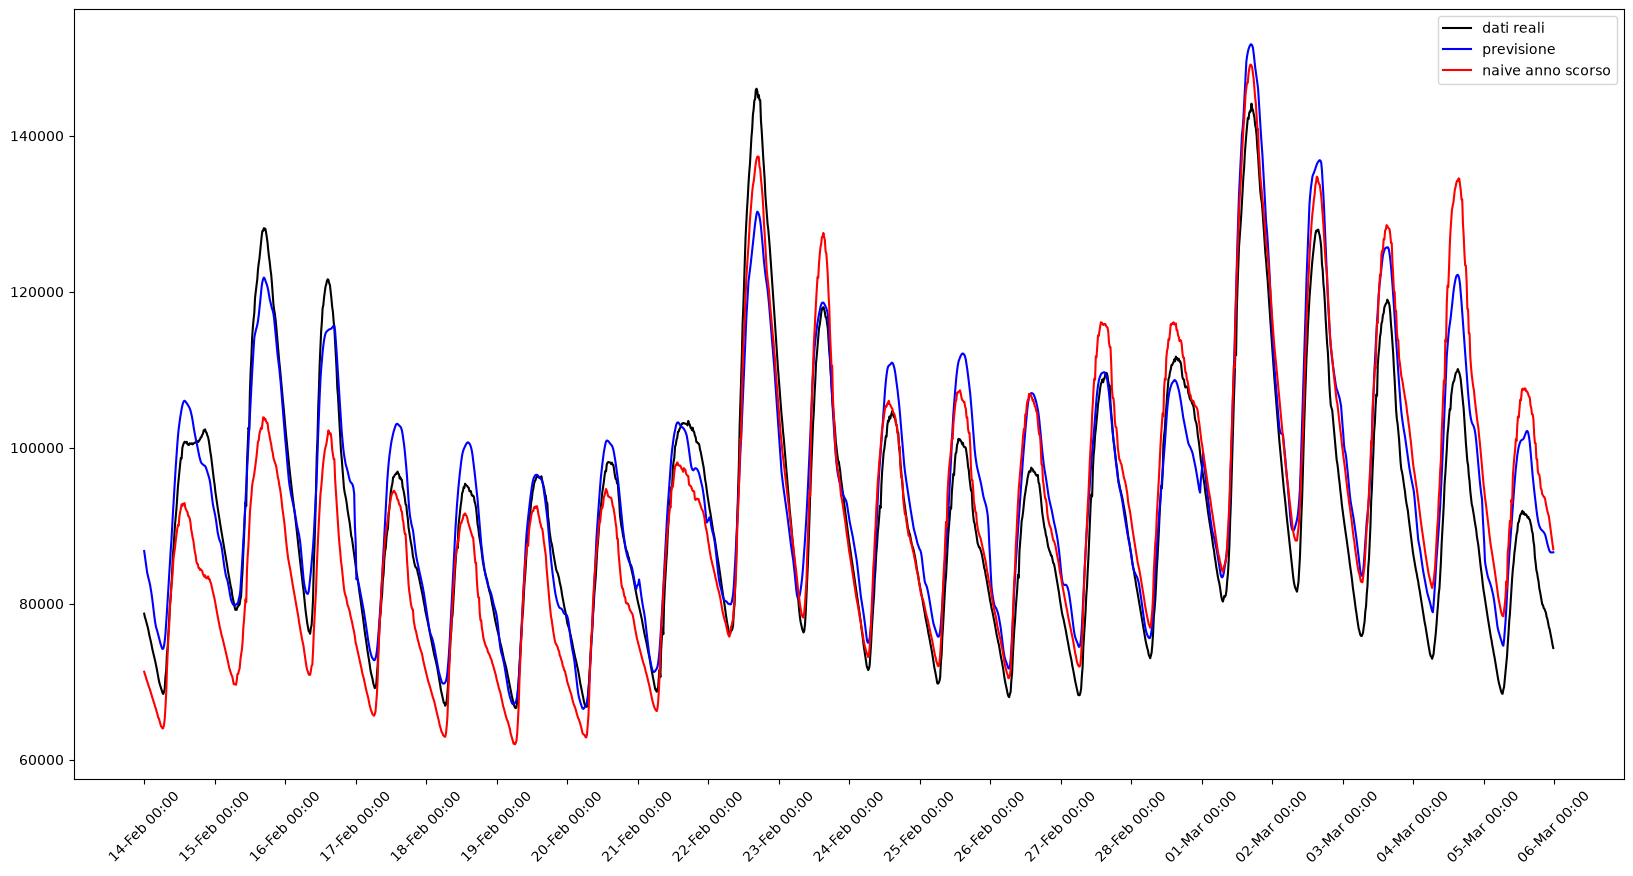

In [41]:
# Previsione completa

plt.figure(figsize=(20, 10))
plt.plot(test['giorno_locale'],y_test,color='black')
plt.plot(test['giorno_locale'],results_smooth,color='blue')
#plt.plot(test['giorno_locale'],results,color='green')
plt.plot(test['giorno_locale'],naive_1_y,color='red')
#plt.legend(['dati reali','previsione smooth','previsione','anno scorso'])
plt.legend(['dati reali','previsione','naive anno scorso'])
plt.gca().xaxis.set_major_locator(mdates.HourLocator(byhour=[0]))  # one tick every 6 hours
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %H:%M')) 
plt.xticks(rotation=45)
plt.show()

In [42]:
#calcolo MAE
mae = mean_absolute_error(y_test, results_smooth)
mae_rough = mean_absolute_error(y_test, results)
mae_1_y = mean_absolute_error(y_test, naive_1_y)

# Calcolo RMSE
rmse = np.sqrt(mean_squared_error(y_test, results_smooth))
rmse_rough = np.sqrt(mean_squared_error(y_test, results))
rmse_1_y = np.sqrt(mean_squared_error(y_test, naive_1_y))

# calcolo MAPE
mape = (mean_absolute_percentage_error(y_test,results_smooth) *100)
mape_rough = (mean_absolute_percentage_error(y_test,results) *100)
mape_1_y = (mean_absolute_percentage_error(y_test,naive_1_y) *100)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape} %")

print("-" * 30) 

print(f"MAE rough: {mae_rough}")
print(f"RMSE rough: {rmse_rough}")
print(f"MAPE rough: {mape_rough} %")

print("-" * 30) 

print(f"MAE 1W 1Y: {mae_1_y}")
print(f"RMSE 1W 1Y: {rmse_1_y}")
print(f"MAPE 1W 1Y: {mape_1_y} %")

MAE: 4774.437638368377
RMSE: 5819.685492268433
MAPE: 5.1422501490133055 %
------------------------------
MAE rough: 4772.774783807719
RMSE rough: 5845.85713876431
MAPE rough: 5.1301374427804864 %
------------------------------
MAE 1W 1Y: 6927.525880603286
RMSE 1W 1Y: 8611.552678508779
MAPE 1W 1Y: 7.459772756767205 %


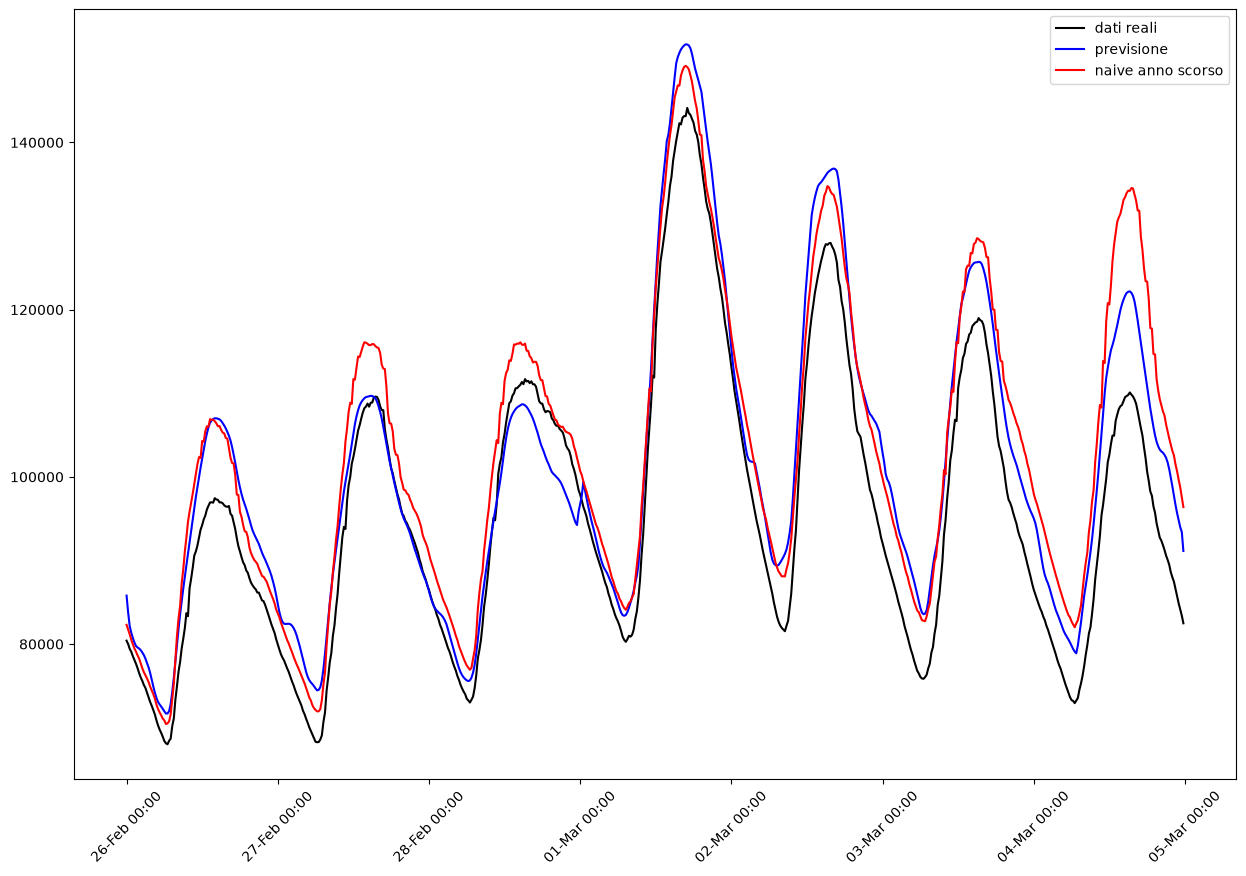

In [43]:
# Previsione settimana

plt.figure(figsize=(15, 10))
plt.plot(test['giorno_locale'][start:end],y_test[start:end],color='black')
plt.plot(test['giorno_locale'][start:end],results_smooth[start:end],color='blue')
#plt.plot(test['giorno_locale'][start:end],results[start:end],color='green')
plt.plot(test['giorno_locale'][start:end],(naive_1_y)[start:end],color='red')
#plt.plot(test['giorno_locale'],y_val,color='green')
#plt.legend(['dati reali','previsione smooth','previsione','anno scorso'])
plt.legend(['dati reali','previsione','naive anno scorso'])
plt.gca().xaxis.set_major_locator(mdates.HourLocator(byhour=[0]))  # one tick every 6 hours
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %H:%M')) 
plt.xticks(rotation=45)
plt.show()

In [44]:
#calcolo MAE
mae = mean_absolute_error(y_test[start:end], results_smooth[start:end])
mae_rough = mean_absolute_error(y_test[start:end], results[start:end])
mae_1_y = mean_absolute_error(y_test[start:end], naive_1_y[start:end])

# Calcolo RMSE
rmse = np.sqrt(mean_squared_error(y_test[start:end], results_smooth[start:end]))
rmse_rough = np.sqrt(mean_squared_error(y_test[start:end], results[start:end]))
rmse_1_y = np.sqrt(mean_squared_error(y_test[start:end], naive_1_y[start:end]))

# calcolo MAPE
mape = (mean_absolute_percentage_error(y_test[start:end],results_smooth[start:end]) *100)
mape_rough = (mean_absolute_percentage_error(y_test[start:end],results[start:end]) *100)
mape_1_y = (mean_absolute_percentage_error(y_test[start:end],naive_1_y[start:end]) *100)

print(f"MAE 1W: {mae}")
print(f"RMSE 1W: {rmse}")
print(f"MAPE 1W: {mape} %")

print("-" * 30) 

print(f"MAE rough 1W: {mae_rough}")
print(f"RMSE rough 1W: {rmse_rough}")
print(f"MAPE rough 1W: {mape_rough} %")

print("-" * 30) 

print(f"MAE 1W 1Y: {mae_1_y}")
print(f"RMSE 1W 1Y: {rmse_1_y}")
print(f"MAPE 1W 1Y: {mape_1_y} %")

MAE 1W: 6002.894506009614
RMSE 1W: 6797.1299802775
MAPE 1W: 6.331077301450675 %
------------------------------
MAE rough 1W: 6002.138471042213
RMSE rough 1W: 6850.111929174391
MAPE rough 1W: 6.309713328149369 %
------------------------------
MAE 1W 1Y: 7002.203399480947
RMSE 1W 1Y: 8432.390089887687
MAPE 1W 1Y: 7.422745449115081 %


### Importance of each variable

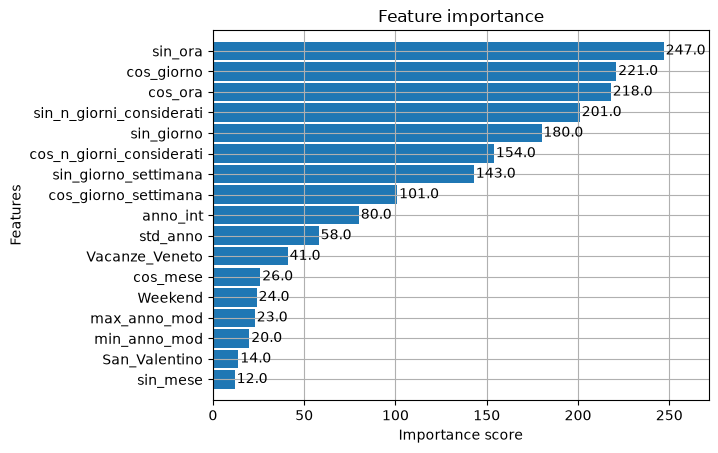

In [45]:
_ = plot_importance(model_fin, height=0.9)

## Saving of the results

In [46]:
prediction_2025 = pd.DataFrame({'data':test['giorno_locale'],'P':results_smooth}).reset_index(drop=True)

path_name = 'Carnevale 2025/xgboost_scalato_carnevale_2025_Dicembre.csv'

if flag_Covid:
    path_name = 'Carnevale 2025/Covid_xgboost_scalato_carnevale_2025_Dicembre.csv'

prediction_2025.to_csv(path_name,index=False)

In [51]:
prediction_2025.head()

,data,P
0,2025-02-14 00:00:00,86760.306869
1,2025-02-14 00:15:00,86050.211225
2,2025-02-14 00:30:00,85358.522605
3,2025-02-14 00:45:00,84677.951049
4,2025-02-14 01:00:00,84023.893830


### Preprocessing and data engeneering for weather data:

In [ ]:
df_previsioni = pd.read_csv('previsioni_meteo_carnevale_tot.csv')
df_previsioni['timeForecast'] = pd.to_datetime(df_previsioni['timeForecast'],unit = 'ms')
df_previsioni = df_previsioni.rename(columns={'timeForecast': 'PrevistePer'})
df_previsioni['partOfDay'] =  df_previsioni['partOfDay'].replace(
    {'m': 'Mattina', 'a': 'Pomeriggio'}).fillna('Giorno completo')
df_previsioni = df_previsioni.drop(columns=['snowAltitude','symbol'])
df_previsioni['Timestamp'] = pd.to_datetime(df_previsioni['Timestamp'])

df_previsioni['PrevistePer'] = df_previsioni['PrevistePer'].dt.tz_localize('Europe/Rome')
df_previsioni['Timestamp'] = df_previsioni['Timestamp'].dt.tz_convert('Europe/Rome')

#Togliamo le colonne doppie il 29-01-2021
df_previsioni = df_previsioni[~((df_previsioni['Timestamp'] == '2021-01-29 12:00:00+00:00') & (df_previsioni['PrevistePer'].dt.hour.isin([4, 16])))]

# Modifica dei primi giorni in modo che siano analoghi a quelli successivi ( Cambio le 16:00 e le 4:00 in PrevistePer in 15:00 e 3:00)
df_previsioni.loc[df_previsioni['PrevistePer'].dt.hour == 4, 'PrevistePer'] = df_previsioni.loc[df_previsioni['PrevistePer'].dt.hour == 4, 'PrevistePer'] - pd.Timedelta(hours=1)
df_previsioni.loc[df_previsioni['PrevistePer'].dt.hour == 16, 'PrevistePer'] = df_previsioni.loc[df_previsioni['PrevistePer'].dt.hour == 16, 'PrevistePer'] - pd.Timedelta(hours=1)

# Suddivisione Giorno completo
# Righe Mattina o Pomeriggio
df_normali = df_previsioni[df_previsioni['partOfDay'] != 'Giorno completo']

# Righe con Giorno completo
df_gc = df_previsioni[df_previsioni['partOfDay'] == 'Giorno completo']

# Riga mattina: 12 ore prima
df_mattina = df_gc.copy()
df_mattina['partOfDay'] = 'Mattina'
df_mattina['PrevistePer'] = df_mattina['PrevistePer'] - pd.Timedelta(hours=12)

# Riga pomeriggio: stessa data
df_pomeriggio = df_gc.copy()
df_pomeriggio['partOfDay'] = 'Pomeriggio'

# Uniamo tutto insieme
df_previsioni = pd.concat([df_normali, df_mattina, df_pomeriggio], ignore_index=True)

# Rimuoviamo le previsioni per il giorno stesso
df_previsioni = df_previsioni[~(df_previsioni['Timestamp'].dt.day == df_previsioni['PrevistePer'].dt.day)]

# Ordiniamo per data
df_previsioni = df_previsioni.sort_values(by=['Timestamp','PrevistePer']).reset_index(drop=True)

df_previsioni['precipitationProbability'] = df_previsioni['precipitationProbability'].str.replace("%", "").astype(float) / 100

# Riempio i missing values in precipitationProbability con 0% siccome segna assenti come precipitation

df_previsioni['precipitationProbability'] = df_previsioni['precipitationProbability'].fillna(value=0)

df_previsioni['giorni_futuri'] = (df_previsioni['PrevistePer']-(df_previsioni['Timestamp'].dt.normalize())).dt.days
df_previsioni

In [ ]:
# Rimuovo i Nan in precipitation:
df_previsioni = df_previsioni.dropna(subset=['precipitation']).copy()

# Mappatura dell'intensità delle precipitazioni in forma numerica
mappa_intensita = {
    "Assenti": 0,
    "Generalmente assenti": 0,
    "Deboli": 1,
    "Deboli intermittenti": 1,
    "Deboli locali": 1,
    "Deboli piogge intermittenti": 1,
    "Deboli piogge locali": 1,
    "Deboli piogge sparse": 1,
    "Deboli sparse": 1,
    "Piogge deboli": 1,
    "Qualche pioggia nel pomeriggio/sera": 1,
    "Qualche pioggia verso sera": 1,
    "Modeste": 2,
    "Modeste locali": 2,
    "Modeste piogge intermittenti": 2,
    "Modeste piogge locali": 2,
    "Modeste piogge sparse": 2,
    "Modeste sparse": 2,
    "Piogge modeste": 2,
    "Moderate": 3,
    "Piogge moderate": 3,
    "Moderate piogge sparse": 3,
    "Consistenti anche a carattere di rovescio/temporale": 4,
    "Piogge anche con rovesci": 4,
    "Piogge sparse anche con rovesci": 4
}
df_previsioni["intensita_pioggia"] = df_previsioni["precipitation"].map(mappa_intensita)

In [ ]:
def temperature_media(row):
    if row['giorni_futuri'] <= 2:
        row = row['temperature']
    else:
        return np.nan
    return (int(row.split('/')[0].strip('min').strip('max').strip()) + int(row.split('/')[1].strip('C').strip()))/2

df_previsioni['temperature'] = df_previsioni.apply(temperature_media,axis=1)

def temperatura_min_max(row):
    df = df_previsioni
    
    tmp_min = df.loc[(df['Timestamp'] == row['Timestamp']) & (df['giorni_futuri'] == row['giorni_futuri']) & (df['partOfDay'] == 'Mattina'),'temperature']
    tmp_max = df.loc[(df['Timestamp'] == row['Timestamp']) & (df['giorni_futuri'] == row['giorni_futuri']) & (df['partOfDay'] == 'Pomeriggio'),'temperature']
    
    tmp_min = tmp_min.iloc[0] if len(tmp_min) > 0 else np.nan
    tmp_max = tmp_max.iloc[0] if len(tmp_max) > 0 else np.nan
    
    return tmp_min,tmp_max

df_previsioni[['temperature_min','temperature_max']] = df_previsioni.apply(lambda row: pd.Series(temperatura_min_max(row)),axis=1)



In [ ]:
# Function to transform each row into a dataset continguous to the main one (one row corresponds to one full day)

def frequenza_15_min(row):
    start_hour = 0 if row["partOfDay"] == "Mattina" else 12
    end_hour = 12 if row["partOfDay"] == "Mattina" else 24
    
    date_range = pd.date_range(
        start=row["PrevistePer"].normalize() + pd.Timedelta(hours=start_hour),
        end=row["PrevistePer"].normalize() + pd.Timedelta(hours=end_hour),
        freq="15min",
        inclusive="left"
    )
    
    if row["giorni_futuri"] <= 2:
        return pd.DataFrame({
            "Timestamp": date_range,
            "intensita_pioggia": row["precipitationProbability"] * row["intensita_pioggia"],
            "temperatura_min": row["temperature_min"],
            "temperatura_max": row["temperature_max"],
        })
    else:
        return pd.DataFrame({
            "Timestamp": date_range,
            "intensita_pioggia": row["precipitationProbability"] * row["intensita_pioggia"],
        })

In [ ]:
# Considero quanti giorni in avanti è fatta la previsione
df_previsioni['giorni_futuri'] = (df_previsioni['PrevistePer']-(df_previsioni['Timestamp'].dt.normalize())).dt.days

#Creazione dataset analogo a quello delle presenze
for data_fut, df_tmp in df_previsioni.groupby('giorni_futuri'):
    df_tmp_i = pd.concat(df_tmp.apply(frequenza_15_min, axis=1).to_list(), ignore_index=True)
    df_tmp_i['intensita_pioggia'] = np.where(df_tmp_i['intensita_pioggia']>0, 1,0)
    if data_fut <= 2:
        df_tmp_i = df_tmp_i.rename(columns={
            "intensita_pioggia": f"previsione_pioggia_g{data_fut}",
            "temperatura_min": f"temperatura_min_g{data_fut}",
            "temperatura_max": f"temperatura_max_g{data_fut}",
        })
    else:
        df_tmp_i = df_tmp_i.rename(columns={
            "intensita_pioggia": f"previsione_pioggia_g{data_fut}",
        })
    
    if data_fut == 1:
        df_previsioni_tot = df_tmp_i
    else:
        df_previsioni_tot = pd.merge(df_previsioni_tot, df_tmp_i, on="Timestamp", how="outer")
df_previsioni_tot['Timestamp'] = df_previsioni_tot['Timestamp'].dt.tz_localize(None)
df_previsioni_tot = df_previsioni_tot.rename(columns={"Timestamp": "giorno_locale"})
for col in df_previsioni_tot.columns:
    if col.startswith("previsione_pioggia"):
        df_previsioni_tot[col] = pd.to_numeric(df_previsioni_tot[col], errors='coerce')

In [ ]:
# Union to the main dataset

df_grouped = df_grouped.merge(df_previsioni_tot, on = 'giorno_locale', how = 'left')